In [1]:
import matplotlib.pyplot as plt
from mlp import MLP
import numpy as np
from value_class import Value

points = [(0, 5),(1, 7),(2, 9),(-1, 3),(3, 12),(4, 15),
    (-2, 1),(5, 20), (0, 1),(1, 2),(2, 5),(-1, 0),(3, 7),
    (4, 8),(-2, -3),(5, 10)]
labels = [1 if y > 2*x + 3 else 0 for x, y in points]
print(labels)

0.7864477329659274
0.9977295560367264
0.4988647780183632
0.9977295560367264
[Value(data=-0.20865902843519596), Value(data=0.18823889958456963), Value(data=-0.28131441620784275)]
[Value(data=-0.601554476486983)]
[1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0]


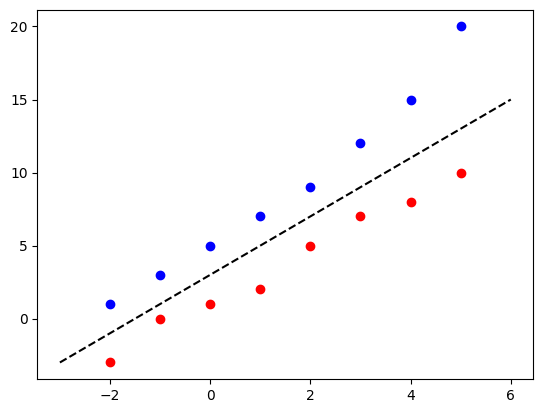

In [2]:
for (x, y), label in zip(points, labels):
    color = 'blue' if label == 1 else 'red'
    plt.scatter(x, y, color=color)
xs = range(-3, 7)
ys = [2*x + 3 for x in xs]
plt.plot(xs, ys, 'k--')
plt.show()

In [3]:
model = MLP(2, [4, 1])
predictions = [model([Value(x), Value(y)]) for x, y in points]
print(predictions[0])

[Value(data=-0.9944639328862707)]


In [4]:
def mse_loss(predictions, labels):
    return sum((p[0] - l)**2 for p, l in zip(predictions, labels)) / len(labels)

loss = mse_loss(predictions, labels)
print(loss)

Value(data=2.2555049455499305)


In [5]:
model = MLP(2, [4, 1])
print(len(model.parameters()))

17


In [7]:
lr = 0.01
for i in range(100):
    predictions = [model([Value(x), Value(y)]) for x, y in points]
    loss = mse_loss(predictions, labels)
    
    for p in model.parameters():
        p.grad = 0

    loss.backward()
    
    for p in model.parameters():
        p.data = p.data - lr * p.grad
    
    if i % 10 == 0:
        print(i, loss.data)

0 0.24320565701349495
10 0.07180501075042861
20 0.06052020412392766
30 0.051927968304769714
40 0.045348176170233394
50 0.04028865754482019
60 0.036372189015692995
70 0.03331530475110453
80 0.030907157955312077
90 0.028991458779676706


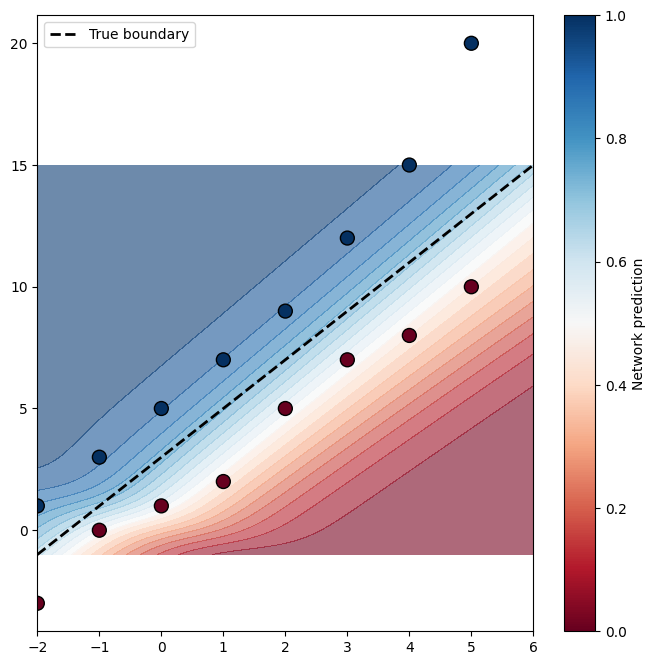

In [8]:

xs = np.linspace(-2, 6, 100)
ys = np.linspace(-1, 15, 100)
Xs, Ys = np.meshgrid(xs, ys)

predictions_grid = []
for i in range(len(xs)):
    row = []
    for j in range(len(ys)):
        pred = model([Value(Xs[j, i]), Value(Ys[j, i])])[0]
        row.append(pred.data)
    predictions_grid.append(row)

predictions_grid = np.array(predictions_grid)

plt.figure(figsize=(8, 8))
plt.contourf(Xs, Ys, predictions_grid.T, levels=20, cmap='RdBu', alpha=0.6)
plt.scatter([x for x, y in points], [y for x, y in points], c=labels, cmap='RdBu', s=100, edgecolors='black')
plt.plot(xs, 2*xs + 3, 'k--', linewidth=2, label='True boundary')
plt.colorbar(label='Network prediction')
plt.legend()
plt.show()